# ALTRA scRNA GSEA - Fig 5H and S11H

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(ggplot2)
quiet_library(forcats)
quiet_library(RColorBrewer)

## Functions

In [3]:
# Function to plot summary heatmap


dotplotHM <- function(df, cell, pathways) {

    a <- df %>%
        filter(grepl(paste0(cell, collapse = '|'), celltype),
               grepl(paste0(pathways, collapse = '|'), pathway))

    ggplot(a, aes(x=padj, 
                  y=pathway, 
                  size=(lesize/gsize)*100,
                  colour=NES)) + 
        geom_count() + 
        aes(y=fct_reorder(pathway, padj, .desc = T)) +
        scale_x_reverse() +
        scale_colour_gradientn(colours = (brewer.pal(9,'BrBG')), 
                               limit = c(-2.5,2.5)) + 
        #scale_colour_viridis(option = 'magma', 
        #                     discrete = FALSE, 
        #                     direction = -1) + 
        theme_bw() + 
        labs(x = 'Adjusted p value', 
             y = 'Enriched pathways', 
             size = '% Enriched') +
        theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
               #legend.position = c(0.85, 0.75),
               #legend.background = element_rect(colour = 'black', size = 0.5),
               legend.text = element_text(size=11), 
               legend.title = element_text(size=11),
               axis.text.y = element_text(size=10),
               axis.text.x = element_text(size=11, angle=45, hjust = 1, vjust =1), 
               axis.title.y = element_text(size=11), 
               axis.title.x = element_text(size=11))

}

## Read in GSEA data

GSEA generated in: <br>
https://github.com/aifimmunology/ALTRA-manuscript/blob/development/Analysis/scRNA/Longitudinal_analysis/01_R_Pseudobulk_longitudinal_DEGs.ipynb

In [4]:
gsea <- read.csv('/home//workspace/temp/scRNA_DEG//ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_AIM3_deg_gsea_pathway.csv',
                 header = T, stringsAsFactors = F)

nrow(gsea)

[1] 1478

## Visualization: Core Naive CD4 T cells

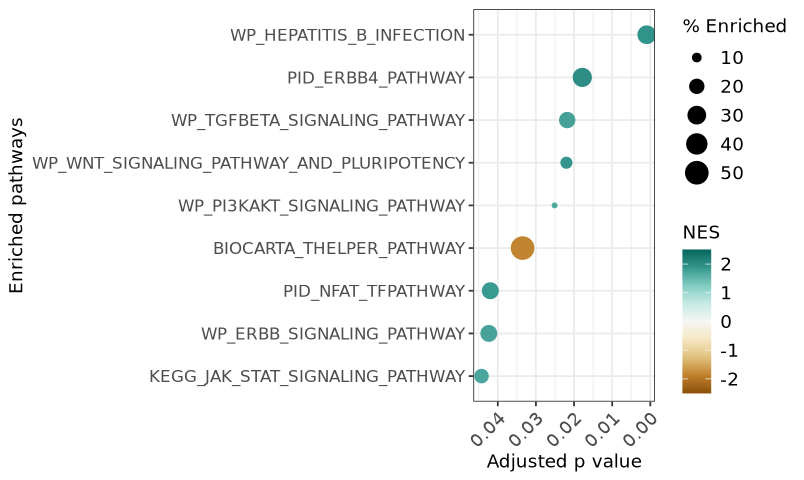

In [5]:
cell <- c('Core naive CD4')

pathways <- c('HEPATITIS', 'ERBB', 'TGF', 'WNT', 'PI3K', 'THELPER', 'NFAT', 'JAK')

options(repr.plot.width = 6.7, repr.plot.height = 4) # default 7x7

p <- dotplotHM(gsea, cell, pathways)

print(p)

In [6]:
ggsave(filename = 'GSEA_naiveCD4_Activation.pdf', 
       #path = 'Figures',
       p,
       device = 'pdf', 
       width = 6.5, 
       height = 4, 
       units = 'in')

## Visualization: Core Naive CD8 T cells

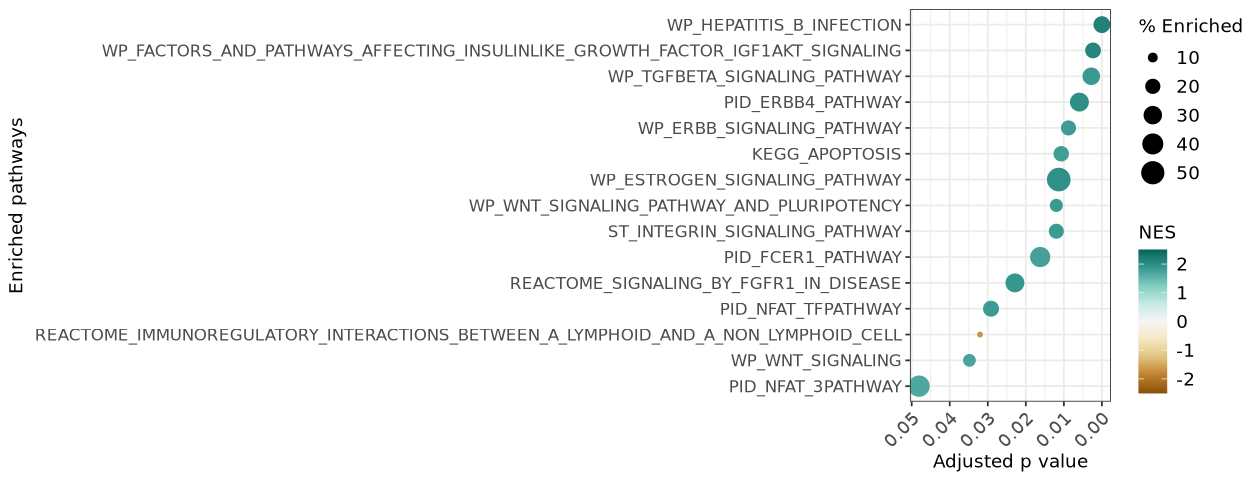

In [7]:
cell <- c('Core naive CD8')

pathways <- c('HEPATITIS', 'INSULIN', 'ERBB', 'TGF', 'WNT', 'APOPTOSIS', 'ESTROGEN', 'INTEGRIN', 'FCER1', 'FGFR1', 'NFAT', 'IMMUNOREGULATORY')

options(repr.plot.width = 10.5, repr.plot.height = 4) # default 7x7

p <- dotplotHM(gsea, cell, pathways)

print(p)

In [8]:
ggsave(filename = 'GSEA_naiveCD8_Activation.pdf', 
       #path = 'Figures',
       p,
       device = 'pdf', 
       width = 10, 
       height = 4, 
       units = 'in')

In [9]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 forcats_1.0.0      ggplot2_3.5.1      dplyr_1.1.4       
[5] hise_2.16.0       

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] tidyselect_1.2.1  IRdisplay_1.1     textshaping_0.4.0 systemfonts_1.1.0
 [9] scales_1